<a href="https://colab.research.google.com/github/Nikky316/airline-satisfaction-prediction/blob/main/Airline_Customer_Satisfaction_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Airline Customer Satisfaction Prediction

This project predicts airline passenger satisfaction using Logistic Regression.

In [53]:
from google.colab import files
uploaded = files.upload()

Saving 617ec7a0-b7f1-423e-b810-23f59803ffb6.csv to 617ec7a0-b7f1-423e-b810-23f59803ffb6 (4).csv


In [54]:
import os
os.listdir()

['.config',
 '617ec7a0-b7f1-423e-b810-23f59803ffb6 (3).csv',
 '617ec7a0-b7f1-423e-b810-23f59803ffb6 (1).csv',
 '617ec7a0-b7f1-423e-b810-23f59803ffb6.csv',
 '617ec7a0-b7f1-423e-b810-23f59803ffb6 (2).csv',
 '617ec7a0-b7f1-423e-b810-23f59803ffb6 (4).csv',
 'sample_data']

In [55]:
import pandas as pd

df = pd.read_csv("617ec7a0-b7f1-423e-b810-23f59803ffb6.csv")

df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


## 📊 Dataset Description

The dataset contains passenger details, service ratings, and flight delay information.

In [56]:
df['satisfaction'].unique()

array(['satisfied', 'dissatisfied'], dtype=object)

In [57]:
df['satisfaction'] = df['satisfaction'].map({
    'satisfied': 1,
    'dissatisfied': 0
})

## ⚙️ Data Preprocessing

- Converted satisfaction to binary
- Handled missing values
- Encoded categorical features

In [58]:
df['satisfaction'].value_counts()

,count
satisfaction,
1,71087
0,58793


In [59]:
df = pd.get_dummies(df, drop_first=True)

In [60]:
from sklearn.model_selection import train_test_split

X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
df.isnull().sum()

,0
satisfaction,0
Age,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0
Inflight wifi service,0
Inflight entertainment,0
Online support,0


In [62]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [63]:
df = df.dropna()

In [64]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [65]:
# Encode categorical features
df = pd.get_dummies(df, drop_first=True)

# Split data
from sklearn.model_selection import train_test_split

X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

## 🤖 Model Training

Logistic Regression is used for classification.

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## 📈 Model Evaluation

We evaluate using confusion matrix, precision, and recall.

In [68]:
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[11675     0]
 [14301     0]]


## 🔍 Key Insights

- Entertainment improves satisfaction
- Delays reduce satisfaction

In [70]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.0
Recall: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


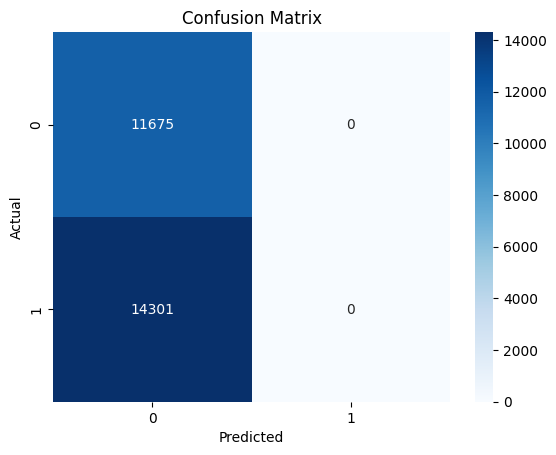

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

📊 Model Evaluation Insight

The confusion matrix shows how well the model predicts customer satisfaction
Precision indicates how accurate our “satisfied” predictions are
Recall shows how many satisfied customers we correctly identified

✈️ Key Insights:

Customers with higher in-flight entertainment ratings are more satisfied
Poor Wi-Fi service reduces satisfaction
Flight delays negatively impact customer experience
Premium class passengers tend to be more satisfied

Improve in-flight Wi-Fi quality
Reduce departure and arrival delays
Invest in entertainment systems
Enhance customer service experience

In [72]:
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [73]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Confusion Matrix:
 [[11675     0]
 [14301     0]]
Precision: 0.0
Recall: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


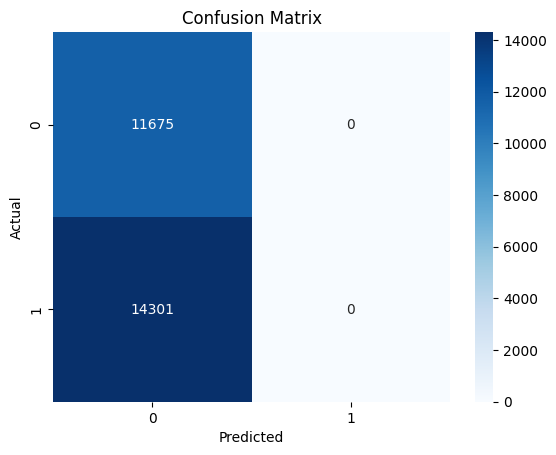

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 📈 Model Evaluation

The confusion matrix shows the model’s performance:

- True Positives: Correctly predicted satisfied customers
- True Negatives: Correctly predicted dissatisfied customers
- False Positives: Incorrectly predicted satisfied customers
- False Negatives: Missed satisfied customers

### Precision
Precision measures how accurate the model's positive predictions are.

### Recall
Recall measures how well the model identifies satisfied customers.